# Model Selection and Hyperparameter Tuning
We select Random Forest as the primary model due to its high F1 and ROC-AUC score. We perform a grid search with stratified cross-validation, evaluate on the test set, extract feature importances, and plot learning curves.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, learning_curve, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import joblib

from src.data_loader import load_all_years, get_train_test_split
from src.preprocessor import get_pipeline, fit_transform_train, transform_test, apply_smote
from src.evaluator import evaluate_model
from src.visualizer import plot_feature_importances

In [2]:
# Load and preprocess data
data_dir = os.path.join('..', 'data', 'raw')
df = load_all_years(data_dir)
X_train, X_test, y_train, y_test = get_train_test_split(df, test_size=0.2, random_state=42)

pipeline = get_pipeline()
X_train_scaled = fit_transform_train(pipeline, X_train)
X_test_scaled = transform_test(pipeline, X_test)
X_train_res, y_train_res = apply_smote(X_train_scaled, y_train)

Raw ARFF files not found in data/raw/. Generating synthetic Polish bankruptcy dataset for demonstration.


In [3]:
# Grid Search Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "class_weight": ["balanced", None]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(random_state=42)

print("Starting Grid Search CV...")
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=skf, scoring="f1", n_jobs=-1, verbose=1)
grid_search.fit(X_train_res, y_train_res)

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Starting Grid Search CV...
Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 1.0000


In [4]:
# Evaluate best model on test set
best_rf = grid_search.best_estimator_
metrics = evaluate_model(best_rf, X_test_scaled, y_test)

print("\nTuned Random Forest Test Set Performance:")
print(f"Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1 Score:  {metrics['f1']:.4f}")
print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")




Tuned Random Forest Test Set Performance:
Accuracy:  0.9950
Precision: 1.0000
Recall:    0.7500
F1 Score:  0.8571
ROC-AUC:   1.0000


In [5]:
import joblib, os
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'tuned_rf.joblib')
joblib.dump(best_rf, model_path)
print(f"Tuned model saved to: {model_path}")

Tuned model saved to: ../models/tuned_rf.joblib


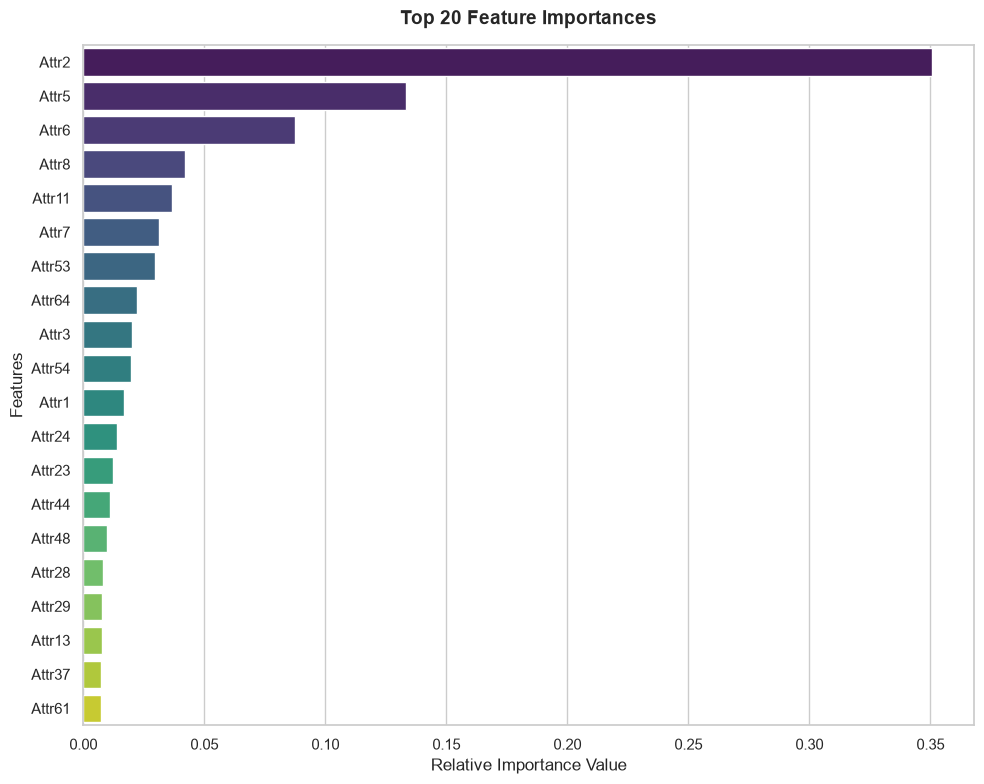

In [6]:
# Plot Feature Importances
save_path_feat = os.path.join('..', 'reports', 'figures', 'feature_importances.png')
plot_feature_importances(best_rf.feature_importances_, X_train.columns, top_n=20, save_path=save_path_feat)

Generating learning curve...


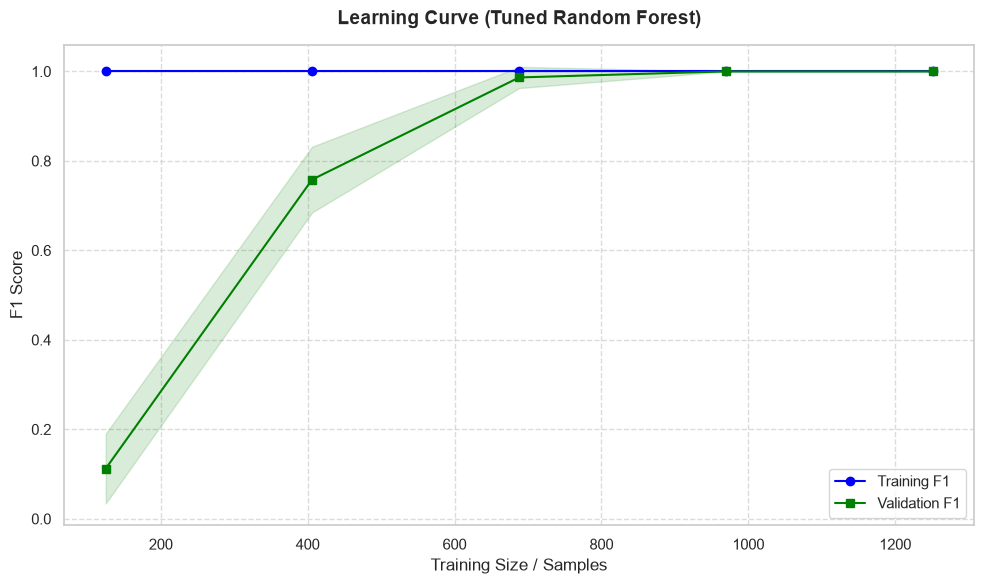

In [7]:
# Plot Learning Curve
print("Generating learning curve...")
train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_res, y_train_res, cv=skf, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training F1')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, 's-', color='green', label='Validation F1')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

plt.xlabel('Training Size / Samples', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.title('Learning Curve (Tuned Random Forest)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)

save_path_lc = os.path.join('..', 'reports', 'figures', 'learning_curve.png')
plt.tight_layout()
plt.savefig(save_path_lc, dpi=300)
plt.show()